In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

In [74]:
df=pd.read_csv("C:\\Users\\Pranjali\\OneDrive\\Desktop\\ml_algorithms\\logistic_regression\\email_spam_detection_project\\email.csv")

In [75]:
df.head()
## int the dataset ham means its good message
## spam means the message is anaonmous

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [76]:
df.shape

(5573, 2)

In [77]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [78]:
df.info

<bound method DataFrame.info of             Category                                            Message
0                ham  Go until jurong point, crazy.. Available only ...
1                ham                      Ok lar... Joking wif u oni...
2               spam  Free entry in 2 a wkly comp to win FA Cup fina...
3                ham  U dun say so early hor... U c already then say...
4                ham  Nah I don't think he goes to usf, he lives aro...
...              ...                                                ...
5568             ham               Will ü b going to esplanade fr home?
5569             ham  Pity, * was in mood for that. So...any other s...
5570             ham  The guy did some bitching but I acted like i'd...
5571             ham                         Rofl. Its true to its name
5572  {"mode":"full"                                    isActive:false}

[5573 rows x 2 columns]>

In [79]:
df.describe

<bound method NDFrame.describe of             Category                                            Message
0                ham  Go until jurong point, crazy.. Available only ...
1                ham                      Ok lar... Joking wif u oni...
2               spam  Free entry in 2 a wkly comp to win FA Cup fina...
3                ham  U dun say so early hor... U c already then say...
4                ham  Nah I don't think he goes to usf, he lives aro...
...              ...                                                ...
5568             ham               Will ü b going to esplanade fr home?
5569             ham  Pity, * was in mood for that. So...any other s...
5570             ham  The guy did some bitching but I acted like i'd...
5571             ham                         Rofl. Its true to its name
5572  {"mode":"full"                                    isActive:false}

[5573 rows x 2 columns]>

In [80]:
df.dtypes

Category    object
Message     object
dtype: object

In [81]:
## convert the messgae to lowercase
df['Message']=df['Message'].str.lower()

In [82]:
## removing stopwords form the messgae
import nltk 
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words=set(stopwords.words('english'))

df['Message']=df['Message'].apply(lambda x :  " ".join
                                   (word for word in x.split()
                                    if word not in stop_words))

df["Message"].head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pranjali\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0    go jurong point, crazy.. available bugis n gre...
1                        ok lar... joking wif u oni...
2    free entry 2 wkly comp win fa cup final tkts 2...
3            u dun say early hor... u c already say...
4              nah think goes usf, lives around though
Name: Message, dtype: object

In [83]:
## removing punctuation form the message 
import string
df['Message']=df['Message'].apply(
    lambda x :
    x.translate(str.maketrans( '','',string.punctuation))
         )

## exploratory data analysis & feature engineering

In [84]:
df['Category'].value_counts()

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

In [85]:
# there is unkonown category 
# {"mode":"full"       1 
# hence used the folling code line to remove that and keep the 2 valid values i.e ham and spam

In [86]:
df=df[df["Category"].isin(['ham','spam'])]

<Axes: xlabel='Category'>

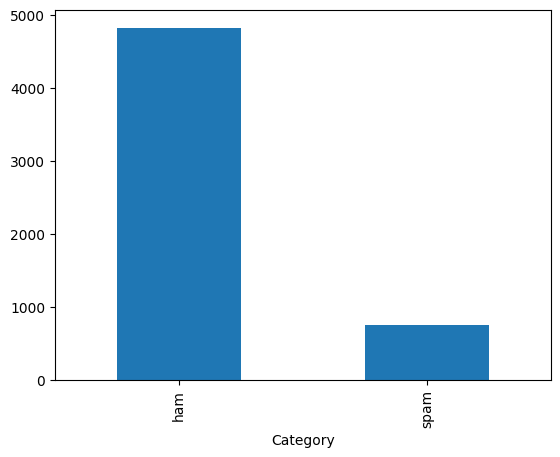

In [87]:
##understnading total counts of values in target variable
df['Category'].value_counts().plot(kind="bar")

In [88]:
## creating a new feature for message lenght
df['message_lenght']=df["Message"].apply(len)

C:\Users\Pranjali\AppData\Local\Temp\ipykernel_16680\2741330216.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['message_lenght']=df["Message"].apply(len)


In [89]:
df.head()

,Category,Message,message_lenght
0,ham,go jurong point crazy available bugis n great ...,82
1,ham,ok lar joking wif u oni,23
2,spam,free entry 2 wkly comp win fa cup final tkts 2...,135
3,ham,u dun say early hor u c already say,35
4,ham,nah think goes usf lives around though,38


<Axes: xlabel='message_lenght', ylabel='Count'>

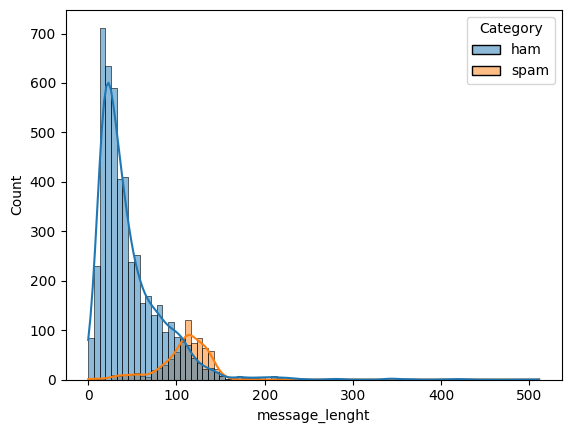

In [90]:
sns.histplot(data=df,x="message_lenght",hue="Category",kde=True)

In [91]:
## so the above graph shows that basically the spam message lenght is liying in the range of 0-200

In [92]:
# creating a new feautre for word count
df["word_count"]=df["Message"].apply(lambda x : len(x.split()))

C:\Users\Pranjali\AppData\Local\Temp\ipykernel_16680\2496463958.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["word_count"]=df["Message"].apply(lambda x : len(x.split()))


In [93]:
df.head()

,Category,Message,message_lenght,word_count
0,ham,go jurong point crazy available bugis n great ...,82,16
1,ham,ok lar joking wif u oni,23,6
2,spam,free entry 2 wkly comp win fa cup final tkts 2...,135,23
3,ham,u dun say early hor u c already say,35,9
4,ham,nah think goes usf lives around though,38,7


<Axes: xlabel='word_count', ylabel='Count'>

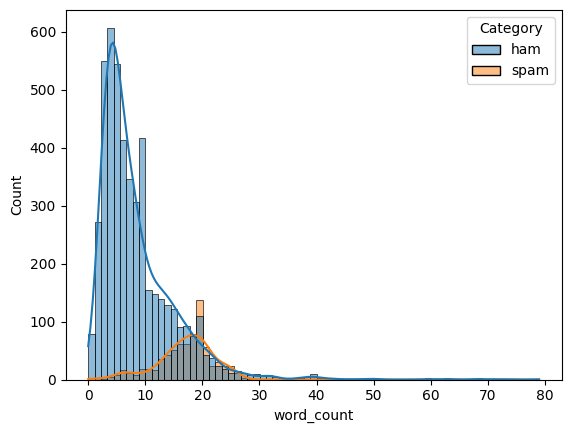

In [94]:
sns.histplot(data=df,x="word_count",hue="Category",kde=True)

In [95]:
## so based on the above graph the spam meesge has the word count apprx in the range 0-150

In [96]:
## most common words checking
## in all messages
from collections import Counter
words=" ".join(df["Message"]).split()

common_words=Counter(words).most_common(20)
print(common_words)


[('u', 1130), ('call', 575), ('2', 482), ('ur', 390), ('get', 386), ('4', 293), ('go', 281), ('ok', 278), ('ltgt', 276), ('free', 275), ('know', 257), ('like', 244), ('got', 239), ('good', 236), ('now', 231), ('come', 229), ('time', 208), ('you', 207), ('day', 203), ('love', 200)]


In [97]:
## most common words in spam
from collections import Counter
spam_words=" ".join(df[df['Category'] == "spam"]["Message"]).split()

common_words_spam=Counter(spam_words).most_common(20)
print(common_words_spam)



[('call', 344), ('free', 216), ('2', 173), ('txt', 150), ('u', 145), ('ur', 144), ('mobile', 123), ('text', 120), ('4', 119), ('stop', 115), ('claim', 111), ('reply', 101), ('now', 96), ('prize', 90), ('get', 83), ('new', 69), ('send', 68), ('nokia', 65), ('cash', 62), ('urgent', 62)]


In [98]:
## most common words in ham
from collections import Counter
ham_words=" ".join(df[df['Category'] == "ham"]["Message"]).split()

common_words_ham=Counter(ham_words).most_common(20)
print(common_words_ham)

[('u', 985), ('2', 309), ('get', 303), ('ltgt', 276), ('ok', 273), ('go', 250), ('ur', 246), ('got', 232), ('know', 232), ('like', 231), ('call', 231), ('come', 227), ('good', 224), ('love', 190), ('time', 189), ('day', 188), ('4', 174), ('you', 172), ('me', 171), ('ü', 169)]


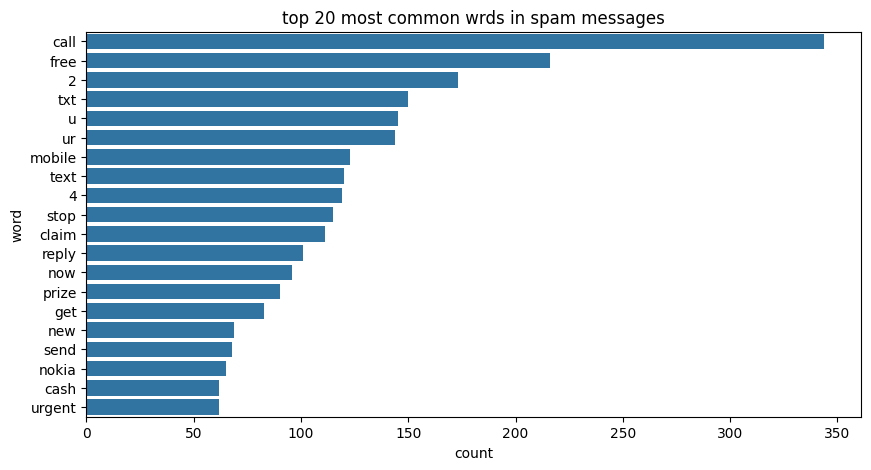

In [99]:
common_words_spam=Counter(spam_words).most_common(20)

spam_df=pd.DataFrame(common_words_spam,columns=["word","count"])

plt.figure(figsize=(10,5))
sns.barplot(data=spam_df,x="count",y="word")
plt.title("top 20 most common wrds in spam messages")
plt.show()

In [100]:
## encoding the target variable
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Category']=encoder.fit_transform(df['Category'])

C:\Users\Pranjali\AppData\Local\Temp\ipykernel_16680\3057975843.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Category']=encoder.fit_transform(df['Category'])


In [101]:
df['Category'].value_counts()

Category
0    4825
1     747
Name: count, dtype: int64

In [108]:
x=df['Message']
y=df['Category']

In [109]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [110]:
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
pipe=Pipeline([
    ('tfidf',TfidfVectorizer()),
    ("model",LogisticRegression())
])


In [111]:
pipe.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [112]:
y_pred=pipe.predict(x_test)

In [114]:
print(accuracy_score(y_test,y_pred))

0.9605381165919282


In [115]:
print(precision_score(y_test,y_pred))

0.9906542056074766


In [116]:
print(recall_score(y_test,y_pred))

0.7114093959731543


In [117]:
print(f1_score(y_test,y_pred))

0.828125


In [118]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.71      0.83       149

    accuracy                           0.96      1115
   macro avg       0.97      0.86      0.90      1115
weighted avg       0.96      0.96      0.96      1115



In [144]:
## testing for the custom message
message="call to you win mobile click the link to claim the reward"


In [145]:
prediction=pipe.predict([message])

In [146]:
if prediction[0] == 1:
    print("Spam email")
else:
    print("safe email")

Spam email


In [147]:
print(pipe.predict_proba([message]))

[[0.44989552 0.55010448]]


In [148]:
##deploying the model
import pickle
with open("spam_model.pkl",'wb') as f:
    pickle.dump(pipe,f)

print("model saved sucessfully")

model saved sucessfully
